<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Анализ-данны-и-добавление-новых-параметров" data-toc-modified-id="Анализ-данны-и-добавление-новых-параметров-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ данны и добавление новых параметров</a></span></li><li><span><a href="#Обучение-моделей" data-toc-modified-id="Обучение-моделей-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение моделей</a></span></li><li><span><a href="#Получение-предсказаний-на-тестовой-выборке" data-toc-modified-id="Получение-предсказаний-на-тестовой-выборке-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Получение предсказаний на тестовой выборке</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Вывод</a></span></li></ul></div>

#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

In [1]:
!pip install -U scikit-learn -q
!pip install optuna -q
!pip install lightgbm -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error as RMSE

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import lightgbm as lgb
from lightgbm import LGBMRegressor

import optuna

In [3]:
RANDOM_STATE = 321
TEST_SIZE = 0.1

## Подготовка

In [4]:
df_taxi = pd.read_csv('https://code.s3.yandex.net/datasets/taxi.csv', index_col='datetime', parse_dates=['datetime'])
df_taxi.sort_index(inplace=True)
df_taxi.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [5]:
df_taxi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [6]:
df_taxi = df_taxi.resample('1H').sum()
df_taxi.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


In [7]:
df_taxi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


Данные загружены. Всего в датасете 26496 записей с данными за пол года в промежутке с 2018-03-01 до 2018-08-31.

После семплирования по 1 часу в датафрейме стало 4416 записей.

## Анализ данны и добавление новых параметров

Разложение временного ряда на тренд и сезонную компоненту для последней недели выборки


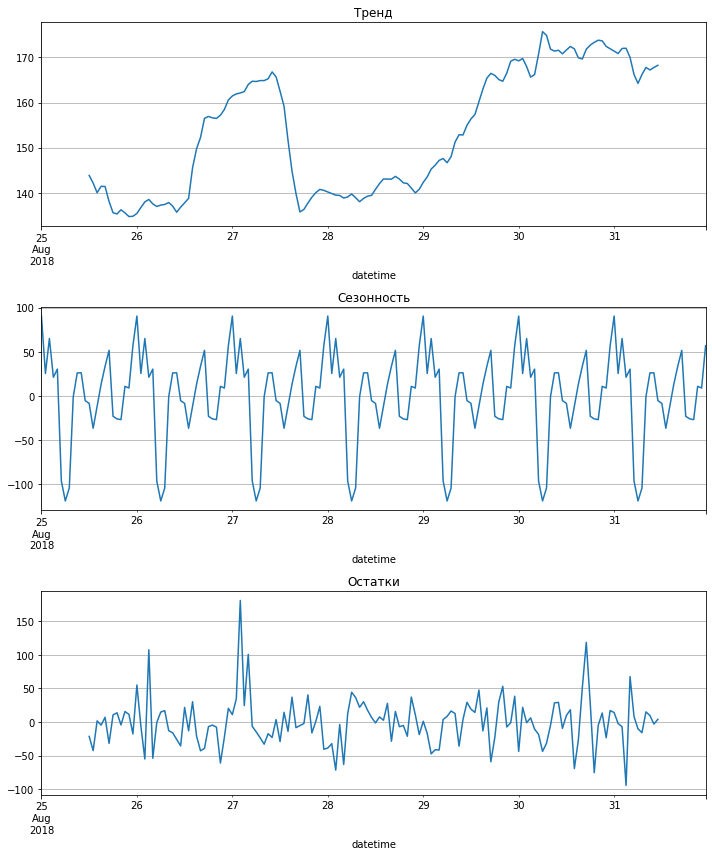

In [8]:
decomposed = seasonal_decompose(df_taxi['2018-08-25':'2018-08-31'])

print('Разложение временного ряда на тренд и сезонную компоненту для последней недели выборки')
plt.figure(figsize=(10, 12))
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Тренд')
plt.grid(True)
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Сезонность')
plt.grid(True)
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Остатки')
plt.grid(True)
plt.tight_layout()

В рамках недели более активный спрос на такси приходится на вторник, четверг и пятницу. В течении дня есть снижение спроса около 6 часов утра и максимальный скачок спроса ближе к концу дня.

Добавление дополнительных параметров для обучения моделей:

In [9]:
def make_features(data, max_lag, rolling_mean_size):
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    
    for i in range(24, max_lag * 24, 24):
        data['lag_'+str(i)] = data['num_orders'].shift(i)
        
    data['rolling_mean'] = data['num_orders'].shift().rolling(rolling_mean_size).mean()

In [10]:
def best_features_params(trial):    
    max_lag = trial.suggest_int("max_lag", 1, 14)
    rolling_mean_size = trial.suggest_int("rolling_mean_size", 3, 50)
    data = df_taxi.copy()
    
    make_features(data=data, max_lag=max_lag, rolling_mean_size=rolling_mean_size)
    
    data = data.dropna()
    
    X_train, X_test, y_train, y_test = train_test_split(
        data.drop(['num_orders'], axis=1),
        data['num_orders'],
        shuffle = False,
        test_size = TEST_SIZE,
        random_state = RANDOM_STATE
    )
    
    model = LinearRegression()
    
    index_output = TimeSeriesSplit(n_splits=5)

    score = cross_val_score(model, X_train, y_train, cv=index_output, scoring='neg_root_mean_squared_error').mean() * -1
    print('Размер выборок X_train, y_train', X_train.shape, y_train.shape)
    print('Значение RMSE:', score)
        
    return score

In [11]:
study = optuna.create_study(direction="minimize")
start = time.time()
study.optimize(best_features_params, n_trials=20, n_jobs=-1)
print(f'Общее время подбора параметров выборки: {(time.time() - start):.3f} секунд')

[I 2025-09-19 22:31:10,622] A new study created in memory with name: no-name-3285ffed-0be0-4d9a-9cf0-8a129025c0c1
[I 2025-09-19 22:31:11,260] Trial 4 finished with value: 25.972065819848517 and parameters: {'max_lag': 3, 'rolling_mean_size': 30}. Best is trial 4 with value: 25.972065819848517.
[I 2025-09-19 22:31:11,346] Trial 2 finished with value: 24.50358118432739 and parameters: {'max_lag': 5, 'rolling_mean_size': 23}. Best is trial 2 with value: 24.50358118432739.


Размер выборок X_train, y_train (3931, 6) (3931,)
Значение RMSE: 25.972065819848517
Размер выборок X_train, y_train (3888, 8) (3888,)
Значение RMSE: 24.50358118432739


[I 2025-09-19 22:31:12,242] Trial 6 finished with value: 24.137457805102656 and parameters: {'max_lag': 7, 'rolling_mean_size': 18}. Best is trial 6 with value: 24.137457805102656.
[I 2025-09-19 22:31:12,345] Trial 0 finished with value: 24.2491546803167 and parameters: {'max_lag': 6, 'rolling_mean_size': 12}. Best is trial 6 with value: 24.137457805102656.


Размер выборок X_train, y_train (3844, 10) (3844,)
Значение RMSE: 24.137457805102656
Размер выборок X_train, y_train (3866, 9) (3866,)
Значение RMSE: 24.2491546803167


[I 2025-09-19 22:31:12,558] Trial 1 finished with value: 24.864194237412672 and parameters: {'max_lag': 6, 'rolling_mean_size': 40}. Best is trial 6 with value: 24.137457805102656.


...

Размер выборок X_train, y_train (3844, 10) (3844,)
Значение RMSE: 24.217390716028138


[I 2025-09-19 22:31:16,945] Trial 15 finished with value: 22.769284371661538 and parameters: {'max_lag': 14, 'rolling_mean_size': 48}. Best is trial 8 with value: 22.446804722026588.
[I 2025-09-19 22:31:17,036] Trial 17 finished with value: 22.80914508399967 and parameters: {'max_lag': 10, 'rolling_mean_size': 36}. Best is trial 8 with value: 22.446804722026588.


Размер выборок X_train, y_train (3693, 17) (3693,)
Значение RMSE: 22.769284371661538
Размер выборок X_train, y_train (3780, 13) (3780,)
Значение RMSE: 22.80914508399967


[I 2025-09-19 22:31:17,055] Trial 19 finished with value: 22.66616364146623 and parameters: {'max_lag': 10, 'rolling_mean_size': 5}. Best is trial 8 with value: 22.446804722026588.
[I 2025-09-19 22:31:17,141] Trial 18 finished with value: 22.6368029684278 and parameters: {'max_lag': 10, 'rolling_mean_size': 7}. Best is trial 8 with value: 22.446804722026588.


Размер выборок X_train, y_train (3780, 13) (3780,)
Значение RMSE: 22.66616364146623
Размер выборок X_train, y_train (3780, 13) (3780,)
Значение RMSE: 22.6368029684278
Общее время подбора параметров выборки: 6.519 секунд


In [12]:
print(f'Значение RMSE кросс-валидационной выборки для модели LinearRegression:\n {study.best_value}')
print(f'Параметры, подобранные для выборки:\n {study.best_params}')

Значение RMSE кросс-валидационной выборки для модели LinearRegression:
 22.446804722026588
Параметры, подобранные для выборки:
 {'max_lag': 9, 'rolling_mean_size': 22}


In [13]:
make_features(df_taxi, **study.best_params)
df_taxi.sample(5)

,num_orders,month,day,dayofweek,lag_24,lag_48,lag_72,lag_96,lag_120,lag_144,lag_168,lag_192,rolling_mean
datetime,,,,,,,,,,,,,
2018-07-18 20:00:00,109,7,18,2,89.0,61.0,100.0,77.0,97.0,85.0,92.0,64.0,100.181818
2018-03-03 18:00:00,68,3,3,5,89.0,73.0,NaN,NaN,NaN,NaN,NaN,NaN,60.909091
2018-07-27 15:00:00,113,7,27,4,104.0,119.0,114.0,118.0,114.0,117.0,67.0,123.0,108.000000
2018-06-26 06:00:00,39,6,26,1,50.0,29.0,40.0,24.0,19.0,95.0,11.0,25.0,85.727273
2018-03-08 00:00:00,143,3,8,3,100.0,42.0,86.0,75.0,163.0,90.0,124.0,NaN,55.454545


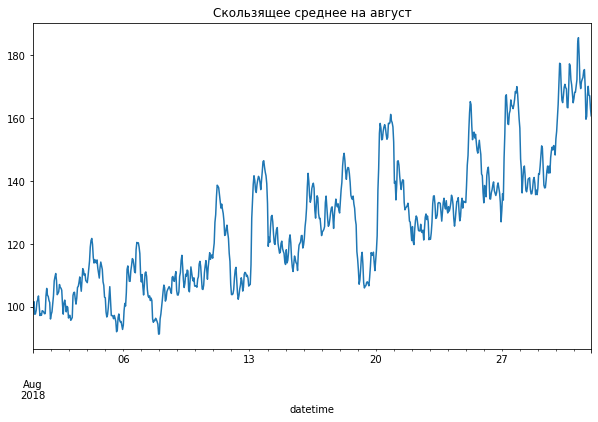

In [14]:
plt.figure(figsize=(10, 6))
df_taxi['2018-08':'2018-08']['rolling_mean'].plot(ax=plt.gca())
plt.title('Скользящее среднее на август')
plt.show()

In [15]:
train, test = train_test_split(df_taxi, shuffle=False, test_size=TEST_SIZE)
train = train.dropna()

X_train = train.drop(['num_orders'], axis=1)
y_train = train['num_orders']

X_test = test.drop(['num_orders'], axis=1)
y_test = test['num_orders']

print('Размер выборок X_train, y_train', X_train.shape, y_train.shape)
print('Размер выборок X_test, y_test', X_test.shape, y_test.shape)

Размер выборок X_train, y_train (3782, 12) (3782,)
Размер выборок X_test, y_test (442, 12) (442,)


Построены графики тренда и сезонности. 

Добавлены дополнительные параметры для обучения моделей:
- месяц
- день месяца
- день недели
- значения количества заказов, выполненных в тот же час днями ранее в параметрах lag
- скользящее среднее в праметре rolling_mean

Количество параметров lag и размер окна для вычисления скользящего были определены с помощью подбора параметров через optuna.

Выполнено разделение данных на тренировочную и тестовую выборки.

## Обучение моделей

In [16]:
pipe_model = Pipeline(
    [
        ('model', LinearRegression())
    ]
)
search_params = [
    {
        'model': [LinearRegression()]
    },
    {
        'model': [RandomForestRegressor(random_state=RANDOM_STATE)],
        'model__n_estimators': [5, 10, 30, 50],
        'model__max_depth': [5, 10, 20],
        'model__min_samples_split': range(2, 5)
    },
    {
        'model': [KNeighborsRegressor()],
        'model__n_neighbors': [5, 8, 11]
    },
    {
        'model': [SVR()],
        'model__kernel': ['linear', 'poly', 'rbf'],
        'model__max_iter': range(5, 20, 3)
    },
    {
        'model': [LGBMRegressor(random_state=RANDOM_STATE)],
        'model__learning_rate': [0.05, 0.1, 0.2, 0.5, 1],
        'model__n_estimators': [10, 40, 80]
    }
]

In [17]:
index_output = TimeSeriesSplit(n_splits = 3)

rs = RandomizedSearchCV(
    pipe_model,
    search_params,
    n_jobs=-1,
    cv=index_output,
    scoring='neg_root_mean_squared_error',
    n_iter=70,
    verbose=10,
    random_state=RANDOM_STATE
)

In [18]:
start = time.time()
rs.fit(X_train, y_train)

print(f'Время выбора и обучения моделей: {(time.time() - start):.3f} секунд')
print()
print('Лучшая модель и её параметры:\n', rs.best_estimator_)
print()
print ('Метрика лучшей модели на кросс валидационной выборке:', rs.best_score_ * -1)

Fitting 3 folds for each of 70 candidates, totalling 210 fits
[CV 1/3; 1/70] START model=LinearRegression()...................................
[CV 1/3; 1/70] END ..model=LinearRegression();, score=-21.168 total time=   0.0s
[CV 2/3; 1/70] START model=LinearRegression()...................................
[CV 2/3; 1/70] END ..model=LinearRegression();, score=-21.257 total time=   0.1s
[CV 3/3; 1/70] START model=LinearRegression()...................................
[CV 3/3; 1/70] END ..model=LinearRegression();, score=-26.652 total time=   0.2s
[CV 1/3; 2/70] START model=RandomForestRegressor(random_state=321), model__max_depth=5, model__min_samples_split=2, model__n_estimators=5
[CV 1/3; 2/70] END model=RandomForestRegressor(random_state=321), model__max_depth=5, model__min_samples_split=2, model__n_estimators=5;, score=-22.177 total time=   0.1s
[CV 2/3; 2/70] START model=RandomForestRegressor(random_state=321), model__max_depth=5, model__min_samples_split=2, model__n_estimators=5
[CV 2

/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=8).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=8).  Consider pre-processing your

[CV 2/3; 46/70] END model=SVR(), model__kernel=poly, model__max_iter=5;, score=-71.960 total time=   0.0s
[CV 3/3; 46/70] START model=SVR(), model__kernel=poly, model__max_iter=5........
[CV 3/3; 46/70] END model=SVR(), model__kernel=poly, model__max_iter=5;, score=-36.318 total time=   0.0s
[CV 1/3; 47/70] START model=SVR(), model__kernel=poly, model__max_iter=8........
[CV 1/3; 47/70] END model=SVR(), model__kernel=poly, model__max_iter=8;, score=-62.732 total time=   0.0s
[CV 2/3; 47/70] START model=SVR(), model__kernel=poly, model__max_iter=8........
[CV 2/3; 47/70] END model=SVR(), model__kernel=poly, model__max_iter=8;, score=-84.780 total time=   0.0s
[CV 3/3; 47/70] START model=SVR(), model__kernel=poly, model__max_iter=8........
[CV 3/3; 47/70] END model=SVR(), model__kernel=poly, model__max_iter=8;, score=-46.860 total time=   0.0s
[CV 1/3; 48/70] START model=SVR(), model__kernel=poly, model__max_iter=11.......
[CV 1/3; 48/70] END model=SVR(), model__kernel=poly, model__max_i

/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=11).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=11).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=11).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=14).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=14).  Consider pre-processing

[CV 1/3; 53/70] END model=SVR(), model__kernel=rbf, model__max_iter=11;, score=-34.176 total time=   0.0s
[CV 2/3; 53/70] START model=SVR(), model__kernel=rbf, model__max_iter=11........
[CV 2/3; 53/70] END model=SVR(), model__kernel=rbf, model__max_iter=11;, score=-32.498 total time=   0.0s
[CV 3/3; 53/70] START model=SVR(), model__kernel=rbf, model__max_iter=11........
[CV 3/3; 53/70] END model=SVR(), model__kernel=rbf, model__max_iter=11;, score=-41.925 total time=   0.0s
[CV 1/3; 54/70] START model=SVR(), model__kernel=rbf, model__max_iter=14........
[CV 1/3; 54/70] END model=SVR(), model__kernel=rbf, model__max_iter=14;, score=-34.292 total time=   0.0s
[CV 2/3; 54/70] START model=SVR(), model__kernel=rbf, model__max_iter=14........
[CV 2/3; 54/70] END model=SVR(), model__kernel=rbf, model__max_iter=14;, score=-32.250 total time=   0.0s
[CV 3/3; 54/70] START model=SVR(), model__kernel=rbf, model__max_iter=14........
[CV 3/3; 54/70] END model=SVR(), model__kernel=rbf, model__max_it

/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=14).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=14).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=17).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=17).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=17).  Consider pre-processing

[CV 1/3; 56/70] END model=LGBMRegressor(random_state=321), model__learning_rate=0.05, model__n_estimators=10;, score=-28.964 total time=   0.1s
[CV 2/3; 56/70] START model=LGBMRegressor(random_state=321), model__learning_rate=0.05, model__n_estimators=10
[CV 2/3; 56/70] END model=LGBMRegressor(random_state=321), model__learning_rate=0.05, model__n_estimators=10;, score=-26.830 total time=   0.1s
[CV 3/3; 56/70] START model=LGBMRegressor(random_state=321), model__learning_rate=0.05, model__n_estimators=10
[CV 3/3; 56/70] END model=LGBMRegressor(random_state=321), model__learning_rate=0.05, model__n_estimators=10;, score=-40.104 total time=   0.2s
[CV 1/3; 57/70] START model=LGBMRegressor(random_state=321), model__learning_rate=0.05, model__n_estimators=40
[CV 1/3; 57/70] END model=LGBMRegressor(random_state=321), model__learning_rate=0.05, model__n_estimators=40;, score=-22.146 total time=   0.4s
[CV 2/3; 57/70] START model=LGBMRegressor(random_state=321), model__learning_rate=0.05, mod

In [19]:
rs_results = pd.DataFrame(rs.cv_results_).sort_values(by='rank_test_score')
rs_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model,param_model__n_estimators,param_model__min_samples_split,param_model__max_depth,param_model__n_neighbors,param_model__max_iter,param_model__kernel,param_model__learning_rate,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.048525,0.037652,0.037551,0.042672,LinearRegression(),NaN,NaN,NaN,NaN,NaN,NaN,NaN,{'model': LinearRegression()},-21.168162,-21.257050,-26.651928,-23.025714,2.564377,1
4,0.262694,0.078675,0.011094,0.000331,RandomForestRegressor(random_state=321),50.0,2.0,5.0,NaN,NaN,NaN,NaN,"{'model__n_estimators': 50, 'model__min_sample...",-22.176877,-21.440341,-28.025412,-23.880877,2.946015,2
12,0.266145,0.071912,0.011334,0.000546,RandomForestRegressor(random_state=321),50.0,4.0,5.0,NaN,NaN,NaN,NaN,"{'model__n_estimators': 50, 'model__min_sample...",-22.195371,-21.435445,-28.020614,-23.883810,2.941568,3
8,0.261032,0.075794,0.011156,0.000387,RandomForestRegressor(random_state=321),50.0,3.0,5.0,NaN,NaN,NaN,NaN,"{'model__n_estimators': 50, 'model__min_sample...",-22.194450,-21.438481,-28.021422,-23.884784,2.941281,4
24,0.505924,0.179984,0.014852,0.000526,RandomForestRegressor(random_state=321),50.0,4.0,10.0,NaN,NaN,NaN,NaN,"{'model__n_estimators': 50, 'model__min_sample...",-21.706835,-22.135440,-27.931233,-23.924503,2.838584,5


Были обучены с подбором гиперпараметров модели LinearRegression, RandomForestRegressor, KNeighborsRegressor, SVR, LGBMRegressor. Среди них с лучшим значением метрики RMSE = 23 на кросс-валидационной выборке была выбрана модель LinearRegression.

## Получение предсказаний на тестовой выборке

In [20]:
y_test_pred = rs.predict(X_test)
print(f'Метрика RMSE на тестовой выборке: {round(RMSE(y_test, y_test_pred), 3)}')

Метрика RMSE на тестовой выборке: 34.443


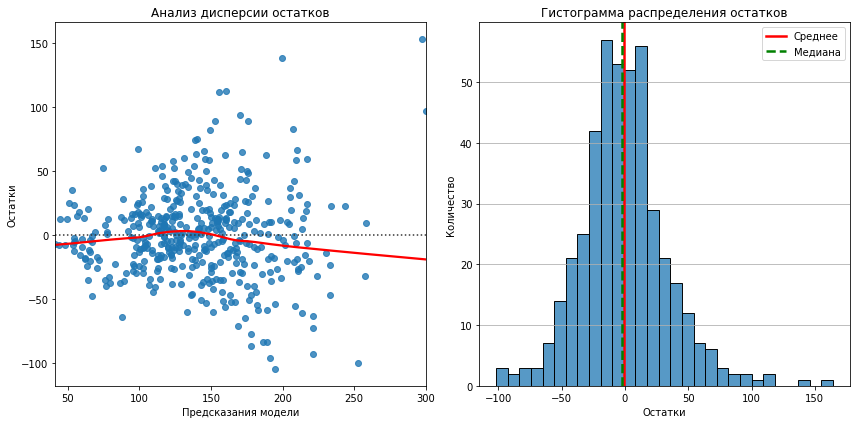

In [21]:
# анализ остатков
residuals = y_test - y_test_pred

fig, (ax_res, ax_hist) = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
sns.residplot(x=y_test_pred, y=residuals, lowess=True, line_kws=dict(color="r"), ax=ax_res)
ax_res.set_title('Анализ дисперсии остатков')
ax_res.set_xlabel('Предсказания модели')
ax_res.set_ylabel('Остатки')

sns.histplot(x=residuals, ax=ax_hist)
ax_hist.axvline(residuals.mean(), c='red', ls='-', lw=2.5, label='Среднее')
ax_hist.axvline(residuals.median(), c='green', ls='--', lw=2.5, label='Медиана')
ax_hist.set_xlabel('Остатки')
ax_hist.set_ylabel('Количество')
ax_hist.set_title('Гистограмма распределения остатков')
ax_hist.legend()
ax_hist.grid(axis='y')
fig.tight_layout()
plt.show()

Были получены предсказания модели на тестовой выборке. Значение RMSE на тестовой выборке не превышает допустимого значения 48 и равно 34,44.

Выполнен анализ остатков. Распределение значений остатков нормальное, среднее около 0, но есть немного выбросов. Дисперсия не совсем равномерная.

## Вывод

В ходе работы над проектом

- Была выполнена подготовка данных: 

данные загружены, обработаны для дальнейшей корректно работы, выполнено семплирование по 1 часу

- Был выполнен анализ данных: 

Построены графики тренда и сезонности. Добавлены дополнительные параметры для обучения моделей:
* месяц
* день месяца
* день недели
* значения количества заказов, выполненных в тот же час днями ранее в параметрах lag
* скользящее среднее в праметре rolling_mean

Количество параметров lag и размер окна для вычисления скользящего были определены с помощью подбора параметров через optuna.

Выполнено разделение данных на тренировочную и тестовую выборки.

- Были обучены модели:

Были обучены с подбором гиперпараметров модели LinearRegression, RandomForestRegressor, KNeighborsRegressor, SVR, LGBMRegressor. Среди них с лучшим значением метрики RMSE = 23 на кросс-валидационной выборке была выбрана модель LinearRegression.

- Была выполнена проверка лучшей модели на тестовой выборке:

Были получены предсказания модели на тестовой выборке. Значение RMSE на тестовой выборке не превышает допустимого значения 48 и равно 34,44.